In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.decomposition import PCA

# ── Configuration ─────────────────────────────────────────────────────────────

NOMINAL_PATH = r"C:\Users\Jacon\OneDrive\Documents\CV 2025\IB\222\Nominal Daily Data(py).csv"
REAL_PATH    = r"C:\Users\Jacon\OneDrive\Documents\CV 2025\IB\222\Real Daily Data(py).csv"

KEY_MATURITIES  = [3, 5, 10, 30]
TENOR_LABELS    = ['3Y', '5Y', '10Y', '30Y']
BOE_TARGET      = 2.0       # percent
NOTIONAL        = 1_000_000 # £1m
COUPON_FREQ     = 2         # semi-annual (standard for gilts)
DATE_FORMAT     = '%d %b %y'

STYLE = {
    'figure.facecolor': '#0d1117',
    'axes.facecolor':   '#161b22',
    'axes.edgecolor':   '#30363d',
    'axes.labelcolor':  '#e6edf3',
    'xtick.color':      '#8b949e',
    'ytick.color':      '#8b949e',
    'text.color':       '#e6edf3',
    'grid.color':       '#21262d',
    'grid.linewidth':   0.8,
    'legend.facecolor': '#161b22',
    'legend.edgecolor': '#30363d',
}
plt.rcParams.update(STYLE)
COLORS = ['#58a6ff', '#3fb950', '#f78166', '#d2a8ff']



## Configuration
- **`BOE_TARGET`** :the 2% inflation target, used as a reference line on the breakeven chart.

In [2]:
# ── Data Loading ───────────────────────────────────────────────────────────────

def load_glc(path: str) -> pd.DataFrame:
    """Load and parse a Bank of England GLC spot yield CSV."""
    df = pd.read_csv(path, nrows=326)  # Read only first 326 rows
    df = df.rename(columns={'years:': 'Date'})
    
    # Try multiple date formats
    df['Date'] = pd.to_datetime(df['Date'], format='%d %b %y', errors='coerce')
    
    # If all NaT, try alternative format
    if df['Date'].isna().all():
        df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
    
    df = df.set_index('Date').sort_index()
    
    # DROP NaT rows
    df = df[df.index.notna()]
    
    # Drop unnamed columns
    df = df.loc[:, ~df.columns.str.contains('^Unnamed')]
    
    df = df.apply(pd.to_numeric, errors='coerce')
    
    print(f"✅ Loaded {len(df)} trading days | First date: {df.index[0]}, Last date: {df.index[-1]}")
    
    return df


def get_key_tenors(df: pd.DataFrame,
                   maturities: list = KEY_MATURITIES,
                   labels: list = TENOR_LABELS) -> pd.DataFrame:
    """Extract and relabel key maturity columns."""
    # Convert df columns to float
    df.columns = df.columns.astype(float)
    subset = df[maturities].copy()
    subset.columns = labels
    return subset

## Data Loading

Two functions that clean and prepare the raw BoE CSV data:

- **`load_glc`** :reads the CSV, fixes the weird `'years:'` column name, converts dates to proper datetime objects, sets the date as the row index, and forces all yield columns to numbers (turning any missing values into `NaN`)

- **`get_key_tenors`** :takes the full DataFrame and extracts just the four maturities you care about (2.5Y, 5Y, 10Y, 30Y), renaming the columns to cleaner labels



In [3]:
def macaulay_duration(ytm: float, coupon_rate: float,
                      maturity: float, freq: int = COUPON_FREQ) -> float:
    """
    Macaulay duration for a coupon-bearing gilt.

    Parameters
    ----------
    ytm         : yield to maturity (decimal, e.g. 0.045)
    coupon_rate : annual coupon rate (decimal); assumed equal to ytm for
                  an at-par gilt — override as needed
    maturity    : years to maturity
    freq        : coupon payments per year (2 = semi-annual)

    Returns
    -------
    Macaulay duration in years
    """
    periods   = int(maturity * freq)
    cf_period = coupon_rate / freq          # coupon per period
    y_period  = ytm / freq                  # yield per period

    times = np.arange(1, periods + 1) / freq
    cash_flows = np.full(periods, cf_period * NOTIONAL)
    cash_flows[-1] += NOTIONAL              # par repayment at maturity

    discount_factors = (1 + y_period) ** -(np.arange(1, periods + 1))
    pv_cfs = cash_flows * discount_factors
    price  = pv_cfs.sum()

    mac_dur = np.dot(times, pv_cfs) / price
    return mac_dur


def modified_duration(ytm: float, coupon_rate: float,
                      maturity: float, freq: int = COUPON_FREQ) -> float:
    """Modified duration = Macaulay duration / (1 + y/freq)."""
    mac = macaulay_duration(ytm, coupon_rate, maturity, freq)
    return mac / (1 + ytm / freq)

# Duration Metrics: Mathematical Foundation

## 1. Bond Pricing Setup

For a coupon-bearing bond with semi-annual payments:

**Number of periods:**
$$n = \text{maturity} \times f$$

where $f = 2$ (semi-annual frequency)

**Cash flow per period:**
$$C = \frac{\text{coupon rate} \times F}{f}$$

where $F$ = face value (notional, typically £100)

**Yield per period:**
$$y = \frac{\text{YTM}}{f}$$

---

## 2. Cash Flow Vector

$$\mathbf{CF} = \begin{bmatrix} C \\ C \\ \vdots \\ C \\ C + F \end{bmatrix} \in \mathbb{R}^n$$

**Code implementation:**
```python
cash_flows = np.full(periods, cf_period * NOTIONAL)  # [C, C, ..., C]
cash_flows[-1] += NOTIONAL                            # Last becomes C + F
```

**Example** (5Y bond, 4% coupon, £100 notional):
$$\mathbf{CF} = [2, 2, 2, 2, 2, 2, 2, 2, 2, 102]$$

---

## 3. Time Vector

Times (in years) when each cash flow occurs:

$$\mathbf{t} = \begin{bmatrix} 0.5 \\ 1.0 \\ \vdots \\ n/f \end{bmatrix}$$

**Code:**
```python
times = np.arange(1, periods + 1) / freq
```

**Example** (5Y, semi-annual):
$$\mathbf{t} = [0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0]$$

---

## 4. Discount Factors

Present value discount factor for period $i$:

$$d_i = \frac{1}{(1+y)^i} = (1+y)^{-i}$$

**Vector form:**
$$\mathbf{d} = \begin{bmatrix} (1+y)^{-1} \\ (1+y)^{-2} \\ \vdots \\ (1+y)^{-n} \end{bmatrix}$$

**Code:**
```python
discount_factors = (1 + y_period) ** -(np.arange(1, periods + 1))
```

**Example** ($y = 2\%$ per period):
$$\mathbf{d} = [0.9804, 0.9612, 0.9423, ...]$$

---

## 5. Present Value of Cash Flows

Element-wise multiplication:

$$\mathbf{PV} = \mathbf{CF} \odot \mathbf{d}$$

where $PV_i = CF_i \cdot d_i = \frac{CF_i}{(1+y)^i}$

**Code:**
```python
pv_cfs = cash_flows * discount_factors  # Element-wise multiplication
```

**Mathematical form:**
$$PV_i = \frac{CF_i}{(1+y)^i}$$

---

## 6. Bond Price

$$P = \sum_{i=1}^{n} PV_i = \sum_{i=1}^{n} \frac{CF_i}{(1+y)^i}$$

**Code:**
```python
price = pv_cfs.sum()
```

**Vector notation:**
$$P = \mathbf{1}^T \mathbf{PV} = \sum_{i=1}^{n} PV_i$$

---

## 7. Macaulay Duration - The Formula

$$D_{Mac} = \frac{1}{P} \sum_{i=1}^{n} t_i \cdot PV_i$$

**In vector notation (dot product):**
$$D_{Mac} = \frac{\mathbf{t}^T \mathbf{PV}}{P}$$

**Code:**
```python
mac_dur = np.dot(times, pv_cfs) / price
```

**Interpretation:** Weighted average time to cash flows

**Weights:**
$$w_i = \frac{PV_i}{P} \quad \text{(proportion of bond value from period } i \text{)}$$

**Then:**
$$D_{Mac} = \sum_{i=1}^{n} t_i \cdot w_i$$

**Note:** $\sum_{i=1}^{n} w_i = 1$ (weights sum to 1)

---

## 8. Numerical Example

**Given:**
- 5-year bond
- 4% coupon (semi-annual)
- 4% yield
- £100 face value

**Step 1:** Calculate cash flows
$$\mathbf{CF} = [2, 2, 2, 2, 2, 2, 2, 2, 2, 102]$$

**Step 2:** Calculate times
$$\mathbf{t} = [0.5, 1.0, 1.5, ..., 5.0]$$

**Step 3:** Discount factors ($y = 0.02$ per period)
$$d_i = (1.02)^{-i}$$

**Step 4:** Present values
$$PV_1 = 2 \times (1.02)^{-1} = 1.961$$
$$PV_{10} = 102 \times (1.02)^{-10} = 83.78$$

**Step 5:** Bond price
$$P = \sum PV_i = 100.00$$

**Step 6:** Macaulay duration
$$D_{Mac} = \frac{0.5 \times 1.961 + 1.0 \times 1.923 + ... + 5.0 \times 83.78}{100} = 4.502 \text{ years}$$

**Financial meaning:** Average time to receive cash flows is 4.5 years (not 5, because coupons arrive early)

---

## 9. Modified Duration

### Relationship to Macaulay:

$$D_{mod} = \frac{D_{Mac}}{1 + y}$$

For semi-annual bonds:
$$\boxed{D_{mod} = \frac{D_{Mac}}{1 + \frac{\text{YTM}}{f}}}$$

**Code:**
```python
mac = macaulay_duration(ytm, coupon_rate, maturity, freq)
return mac / (1 + ytm / freq)
```

**Numerical example:**
$$D_{mod} = \frac{4.502}{1 + 0.04/2} = \frac{4.502}{1.02} = 4.414 \text{ years}$$

---

## 10. Price Sensitivity Interpretation

Modified duration gives approximate percentage price change:

$$\frac{\Delta P}{P} \approx -D_{mod} \cdot \Delta y$$

**Example:** $D_{mod} = 4.414$ years

| Yield Change | Price Change |
|--------------|--------------|
| $+1\%$ | $-4.414\%$ |
| $+0.5\%$ | $-2.207\%$ |
| $-1\%$ | $+4.414\%$ |

**Financial meaning:** Bond has 4.414 years of interest rate risk exposure

---


```

---

## 12. Why This Matters for Trading

**Duration tells you:**
1. **How much interest rate risk** you're taking
2. **How to hedge** your bond position
3. **Position sizing** based on risk tolerance

**Example hedge:**
- Long £10M of 10Y gilt ($D_{mod} = 8.5$)
- Short £X of 2Y gilt ($D_{mod} = 1.9$) to be duration neutral

**Solve:** $10M \times 8.5 = X \times 1.9$

$$X = \frac{10M \times 8.5}{1.9} = £44.7M$$

**Duration-matched hedge:** eliminates parallel yield curve shifts

---

In [4]:
def convexity(ytm: float, coupon_rate: float,
              maturity: float, freq: int = COUPON_FREQ) -> float:
    """
    Full convexity for a coupon-bearing gilt.

    Convexity = (1/P) * Σ [ t(t+1/freq) * CF_t / (1+y/freq)^(t*freq+2) ]
    """
    periods   = int(maturity * freq)
    cf_period = coupon_rate / freq
    y_period  = ytm / freq

    cash_flows = np.full(periods, cf_period * NOTIONAL)
    cash_flows[-1] += NOTIONAL

    price = sum(cash_flows[i] / (1 + y_period)**(i+1) for i in range(periods))

    cvx = 0.0
    for i in range(periods):
        t = i + 1
        cvx += cash_flows[i] * t * (t + 1) / (1 + y_period)**(t + 2)

    return cvx / (price * freq**2)


def price_change_pct(mod_dur: float, cvx: float, dy: float) -> float:
    """
    Second-order price change approximation.
    ΔP/P ≈ -ModDur·Δy + 0.5·Convexity·Δy²
    """
    return -mod_dur * dy + 0.5 * cvx * dy**2

# Convexity: Mathematical Breakdown

## 0. Why This Matters

**The problem:** Duration tells you price changes in a *straight line*. Reality is curved.

**The solution:** Convexity captures the curvature.

**Practical impact:** In a 100 bps (basis points = 0.01%) yield move, convexity can swing your P&L (profit/loss) by 5–10 bps. It always helps you — you profit from volatility either direction.

```
Price
  ^
  |      ╱╱  Reality (curved)
  |    ╱╱
  |  ╱╱      ← Convexity benefit
  |╱ ←────── Duration only (straight line)
  └─────────→ Yield
```

---

## 1. Taylor Expansion: Approximating Price Changes

### The Setup

**Bond price depends on yield:**
$$P(y) = \sum_{i=1}^{n} \frac{CF_i}{(1+y)^{t_i}}$$

**Question:** If yield changes by $\Delta y$, how much does price change?

**Answer (Taylor expansion):**

$$P(y_0 + \Delta y) = P(y_0) + \underbrace{\frac{dP}{dy}\bigg|_{y_0} \Delta y}_{\text{Slope}} + \underbrace{\frac{1}{2}\frac{d^2P}{dy^2}\bigg|_{y_0} (\Delta y)^2}_{\text{Curvature}} + \text{(tiny terms)}$$

**As percentage price change:**

$$\boxed{\frac{\Delta P}{P} = -D_{mod} \cdot \Delta y + \frac{1}{2} C \cdot (\Delta y)^2}$$

where:
- $D_{mod}$ = modified duration (first derivative = slope)
- $C$ = convexity (second derivative = curvature)

### What This Means

- **First term** ($-D_{mod} \cdot \Delta y$): Linear price change (what duration tells you)
- **Second term** ($\frac{1}{2} C \cdot (\Delta y)^2$): Extra gain from curvature (always positive)

The second term is *always* positive because $(\Delta y)^2$ is always positive. So **convexity always helps**, whether yields rise or fall.

---

## 2. The Derivatives

### First Derivative (Modified Duration)

**Start:** 
$$P(y) = \sum_{i=1}^{n} \frac{CF_i}{(1+y)^{t_i}}$$

**Differentiate (using chain rule):**
$$\frac{dP}{dy} = \sum_{i=1}^{n} CF_i \cdot (-t_i) \cdot (1+y)^{-(t_i+1)}$$

**Normalize by price (to get percentage change):**
$$\frac{1}{P}\frac{dP}{dy} = -\frac{\sum t_i \cdot PV_i}{P} = -D_{mod}$$

**English:** "For every 1% yield increase, price falls by $D_{mod}$%"

---

### Second Derivative (Convexity)

**Differentiate the first derivative again:**
$$\frac{d^2P}{dy^2} = \sum_{i=1}^{n} CF_i \cdot (-t_i) \cdot (-(t_i+1)) \cdot (1+y)^{-(t_i+2)}$$

$$\frac{d^2P}{dy^2} = \sum_{i=1}^{n} CF_i \cdot t_i(t_i+1) \cdot (1+y)^{-(t_i+2)}$$

**Normalize by price:**
$$C = \frac{1}{P}\frac{d^2P}{dy^2} = \frac{1}{P}\sum_{i=1}^{n} CF_i \cdot t_i(t_i+1) \cdot (1+y)^{-(t_i+2)}$$

**For semi-annual gilts** (adjust for $f=2$ frequency):
$$\boxed{C = \frac{1}{P \cdot f^2} \sum_{i=1}^{n} CF_i \cdot i(i+1) \cdot (1+y)^{-(i+2)}}$$

---

## 3. Numerical Example: 5Y Gilt

**Given:**
- Maturity: 5 years
- Coupon: 4% annual (2% per period, semi-annual)
- YTM: 4% (2% per period = 0.02)
- Notional: £100
- Periods: $n = 5 \times 2 = 10$

### Step 1: Cash Flows

$$\mathbf{CF} = [2, 2, 2, 2, 2, 2, 2, 2, 2, 102]$$

(2% coupon each period, except last period which includes £100 par)

### Step 2: Bond Price

$$P = \sum_{i=1}^{10} \frac{CF_i}{(1.02)^i}$$

| Period | Cash Flow | Discount | Present Value |
|--------|-----------|----------|----------------|
| 1 | £2 | 0.9804 | £1.96 |
| 2 | £2 | 0.9612 | £1.92 |
| 3 | £2 | 0.9423 | £1.88 |
| 4 | £2 | 0.9238 | £1.85 |
| 5 | £2 | 0.9057 | £1.81 |
| 6 | £2 | 0.8880 | £1.78 |
| 7 | £2 | 0.8706 | £1.74 |
| 8 | £2 | 0.8535 | £1.71 |
| 9 | £2 | 0.8368 | £1.67 |
| 10 | £102 | 0.8203 | £83.71 |
| | | **Total** | **£100.00** |

(At-par bond: coupon = yield, so price = par)

### Step 3: Convexity Numerator

For each period, calculate: $CF_i \times i(i+1) \times (1.02)^{-(i+2)}$

| $i$ | $CF_i$ | $i(i+1)$ | $(1.02)^{-(i+2)}$ | Term |
|-----|--------|----------|-------------------|------|
| 1 | 2 | 2 | 0.9423 | 3.77 |
| 2 | 2 | 6 | 0.9238 | 11.09 |
| 3 | 2 | 12 | 0.9057 | 21.74 |
| 4 | 2 | 20 | 0.8880 | 35.52 |
| 5 | 2 | 30 | 0.8706 | 52.24 |
| 6 | 2 | 42 | 0.8535 | 71.69 |
| 7 | 2 | 56 | 0.8368 | 93.80 |
| 8 | 2 | 72 | 0.8203 | 118.12 |
| 9 | 2 | 90 | 0.8043 | 144.77 |
| 10 | 102 | 110 | 0.7885 | 8,857.44 |
| | | | **Sum** | **9,410.18** |

### Step 4: Final Convexity

$$C = \frac{9,410.18}{100 \times 4} = \frac{9,410.18}{400} = 23.53 \text{ years}^2$$

(The units are years-squared because we're measuring curvature)

---

## 4. Price Sensitivity: Real Example

**5Y gilt:** ModDur = 4.5 years, Convexity = 23.53

### Scenario 1: Yields rise 100 bps (+1%)

$$\frac{\Delta P}{P} = -4.5 \times 0.01 + \frac{1}{2} \times 23.53 \times (0.01)^2$$

$$= -0.045 + 0.001177 = -0.0438 = -4.38\%$$

- **Duration effect:** -4.50%
- **Convexity benefit:** +0.12%
- **Net:** -4.38%

### Scenario 2: Yields fall 100 bps (-1%)

$$\frac{\Delta P}{P} = -4.5 \times (-0.01) + \frac{1}{2} \times 23.53 \times (-0.01)^2$$

$$= +0.045 + 0.001177 = +0.0462 = +4.62\%$$

- **Duration effect:** +4.50%
- **Convexity benefit:** +0.12%
- **Net:** +4.62%

**Key insight:** You gain 0.12% from convexity either way. This is why positive convexity is valuable.

---

---

In [5]:
# ── Swap Pricing ───────────────────────────────────────────────────────────────

def build_discount_factors(spot_curve: pd.Series) -> dict:
    """
    Bootstrap OIS-style discount factors from a par spot curve.

    Uses the bootstrapping identity:
        DF(T) = (1 - c * Σ DF(t<T)) / (1 + c)
    where c is the par coupon (annual, Act/365 simplified).

    Parameters
    ----------
    spot_curve : Series indexed by integer maturities (1, 2, ..., N),
                 values in percent

    Returns
    -------
    dict of {maturity: discount_factor}
    """
    dfs = {}
    for T, rate in spot_curve.items():
        c = rate / 100
        prior_sum = sum(c * dfs[t] for t in dfs.keys() if t < T)
        dfs[T] = (1 - prior_sum) / (1 + c)
    return dfs


def price_irs(fixed_rate: float, swap_maturity: int,
              discount_factors: dict, notional: float = NOTIONAL) -> dict:
    """
    Price a vanilla fixed-for-floating GBP IRS against SONIA.
    """
    # Get all available tenors up to swap maturity
    tenors = [t for t in discount_factors.keys() if t <= swap_maturity]
    tenors = sorted(tenors)
    
    if not tenors:
        raise ValueError("Discount factors don't cover swap maturity.")

    annuity = sum(discount_factors[t] for t in tenors)

    # Par swap rate using the last tenor
    df_T = discount_factors[max(tenors)]
    par_swap_rate = (1 - df_T) / annuity

    fixed_pv    = fixed_rate * annuity * notional
    floating_pv = (1 - df_T) * notional
    mtm_value   = floating_pv - fixed_pv

    return {
        'swap_rate':    par_swap_rate,
        'annuity':      annuity,
        'fixed_pv':     fixed_pv,
        'floating_pv':  floating_pv,
        'mtm_value':    mtm_value,
    }

# Swap Pricing: Bootstrapping & Valuation

## 0. Why This Matters

**Problem:** You have a yield curve (spot rates). You need to price swaps.

**Solution:** Convert spot rates → discount factors → swap value

This is the foundation of rates trading. Every desk does this first.

---

## 1. Discount Factors: Converting Yields to Present Values

### The Concept

**Discount factor = "How much is £1 in T years worth today?"**

Example:
- DF(1Y) = 0.96 → £1 in 1 year = £0.96 today
- DF(5Y) = 0.82 → £1 in 5 years = £0.82 today

---

### The Bootstrap Formula

**At each maturity T, a par bond satisfies:**

$$P = c \cdot DF(1) + c \cdot DF(2) + ... + (c+1) \cdot DF(T) = 1$$

where $c$ = par coupon (annual, as decimal)

**Rearranging to solve for DF(T):**

$$\boxed{DF(T) = \frac{1 - c \sum_{t=1}^{T-1} DF(t)}{1 + c}}$$

**In words:** DF(T) depends on all previous DFs. Build iteratively from 1Y → N years.

---

### Numerical Example: 3-Year Bootstrap

**Given spot rates:**

| Maturity | Rate |
|----------|------|
| 1Y | 4.0% |
| 2Y | 4.5% |
| 3Y | 5.0% |

**DF(1):**
$$DF(1) = \frac{1 - 0}{1 + 0.04} = \frac{1}{1.04} = 0.9615$$

**DF(2):**
$$\text{prior\_sum} = 0.045 \times 0.9615 = 0.0433$$
$$DF(2) = \frac{1 - 0.0433}{1 + 0.045} = \frac{0.9567}{1.045} = 0.9153$$

**DF(3):**
$$\text{prior\_sum} = 0.05(0.9615 + 0.9153) = 0.0939$$
$$DF(3) = \frac{1 - 0.0939}{1 + 0.05} = \frac{0.9061}{1.05} = 0.8629$$

**Result:**
```
DF(1) = 0.9615
DF(2) = 0.9153
DF(3) = 0.8629
```

---



## 2. Interest Rate Swaps: Pricing Fixed-for-Floating

### What Is a Swap?

**You:** Pay fixed rate $r$ annually  
**Counterparty:** Pay floating rate (SONIA) annually  
**Notional:** £N  
**Duration:** T years

**At inception:** Fixed rate is set so PV(fixed leg) = PV(floating leg). Swap is worth 0.

**Later:** If rates change, swap gains/loses value.

---

### The Par Swap Rate Formula

**Floating leg PV (at inception):**

The floating rate is expected to equal the forward rate at each date. By a no-arbitrage argument:

$$PV(\text{floating}) = \text{Notional} \times (1 - DF(T))$$

**Fixed leg PV:**

$$PV(\text{fixed @ rate } S) = S \times \text{Annuity} \times \text{Notional}$$

where annuity = $\sum_{t=1}^{T} DF(t)$ (PV of £1 paid annually for T years)

**Par swap rate (where PV(fixed) = PV(floating)):**

$$\boxed{S = \frac{1 - DF(T)}{\sum_{t=1}^{T} DF(t)}}$$

---

### Numerical Example: 3-Year Swap Pricing

**Using DFs from above:**
- DF(1) = 0.9615, DF(2) = 0.9153, DF(3) = 0.8629
- Notional = £1,000,000

**Step 1: Calculate annuity**

$$\text{Annuity} = 0.9615 + 0.9153 + 0.8629 = 2.7397$$

**Step 2: Par swap rate**

$$S = \frac{1 - 0.8629}{2.7397} = \frac{0.1371}{2.7397} = 0.0500 = 5.00\%$$

**English:** Fair fixed rate is 5.00%

---

**Step 3: Price an off-market swap**

**Scenario:** You agreed to pay fixed at 4.80% (below market). What's your position worth?

$$PV(\text{fixed @ 4.8\%}) = 0.048 \times 2.7397 \times 1,000,000 = £131,505$$

$$PV(\text{floating}) = (1 - 0.8629) \times 1,000,000 = £137,100$$

$$MTM = £137,100 - £131,505 = £5,595$$

**English:** You locked in below market → profit £5,595

**Alternative formula:**
$$MTM = (S - r_{\text{fixed}}) \times \text{Annuity} \times \text{Notional}$$
$$= (0.05 - 0.048) \times 2.7397 \times 1,000,000 = £5,479$$

*(Small difference due to rounding)*

---



## 3. Risk Metric: DV01

**How much your position changes per 1 basis point (0.01%) rate move:**

$$\boxed{DV01 = \frac{\text{Annuity} \times \text{Notional}}{10,000}}$$

**Example (3Y swap):**
$$DV01 = \frac{2.7397 \times 1,000,000}{10,000} = £273.97$$

**Interpretation:** Every 1 bp move = ±£273.97 P&L

**For hedging:** If you're long a 10Y swap (DV01 = £500), short £500/300 = £1.67m of 2Y swaps to hedge 1-year key rate duration.

---


---

In [6]:
# ── Relative Value: Slope & Butterfly ─────────────────────────────────────────

def compute_slope(curve: pd.DataFrame,
                  short_tenor: str = '3Y',
                  long_tenor:  str = '30Y') -> pd.Series:
    """2s30s slope in basis points."""
    return (curve[long_tenor] - curve[short_tenor]) * 100


def compute_butterfly(curve: pd.DataFrame,
                      front: str = '3Y',
                      belly: str = '10Y',
                      back:  str = '30Y') -> pd.Series:
    """
    2s10s30s butterfly spread (basis points).
    Positive = belly cheap relative to wings.
    """
    return (curve[belly] - 0.5 * (curve[front] + curve[back])) * 100

# Relative Value: Slope & Butterfly

## 0. Why This Matters

**Problem:** The yield curve isn't flat. You want to trade the shape, not the level.

**Solution:** Measure curve structure → identify mispricings → execute relative value trades

Two key metrics: **slope** (steepness) and **butterfly** (convexity).

---

## 1. Slope: The 2s30s Spread

### What It Measures

**How steep is the yield curve?** Compare long-term yields to short-term yields.

$$\boxed{\text{Slope} = (Y_{30Y} - Y_{2.5Y}) \times 100 \text{ (basis points)}}$$

The slope tells you: "How much extra yield do you earn for lending 30 years instead of 2.5 years?"

---

### Interpretation

| Slope (bps) | Curve Shape | Market Signal |
|-------------|-------------|---------------|
| **200+** | Steep | Growth expected, term premium high, QT (quantitative tightening) effects |
| **100–150** | Normal | Standard risk compensation, neutral positioning |
| **50–100** | Flattening | Monetary tightening, growth concerns |
| **Negative** | Inverted | Severe recession signal (rare for gilts) |

**English:** A steep curve rewards you for duration (bond duration = how sensitive the price is to yield changes) risk. A flat curve doesn't.

---

### Numerical Example

**Today's gilt yields:**

| Maturity | Yield |
|----------|-------|
| 2.5Y | 4.20% |
| 30Y | 4.80% |

**Calculation:**
$$\text{Slope} = (4.80 - 4.20) \times 100 = 60 \text{ bps}$$

**Interpretation:** You earn an extra 60 basis points per year (0.6%) for extending duration from 2.5Y to 30Y.

---

### Historical Context

**Why slope matters for rates desks:**

1. **Term premium (compensation for interest rate risk):** Longer bonds have more duration risk → higher yields
2. **Growth expectations:** If growth is expected, long rates rise more than short rates → steeper curve
3. **Central bank policy:** Flat yield curves often precede recessions (inverted curves signal high recession risk)

**For your portfolio:**
- If slope is **high relative to history** → consider selling slope (buy short, sell long)
- If slope is **low relative to history** → consider buying slope (sell short, buy long)

---

### Trading Application: Slope Trade

**Scenario:** Historical average slope = 100 bps. Today's slope = 60 bps (flatter than normal).

**Thesis:** Slope will steepen back to 100 bps.

**Trade:**
- **Long:** 30Y gilts (benefit if long yields fall relative to short)
- **Short:** 2.5Y gilts (lose if they fall, gain if they rise)
- **Net:** Receive steepening (make money if slope widens from 60 → 100 bps)

**P&L example:**
- Buy £10M 30Y, sell £X of 2.5Y (duration-weighted hedge)
- If 30Y yields fall 20 bps and 2.5Y unchanged: Slope widens, you profit

---

## 2. Butterfly: The 2s10s30s Spread

### What It Measures

**Is the middle of the curve fairly priced?** Compare the belly (10Y) to the wings (2.5Y and 30Y).

$$\boxed{\text{Butterfly} = \left(Y_{10Y} - \frac{Y_{2.5Y} + Y_{30Y}}{2}\right) \times 100 \text{ (basis points)}}$$

**Visual intuition:**

```
Yield
  ^
  |        ╱╲      ← Positive butterfly (belly cheap, above the line)
  |      ╱    ╲
  |    ╱        ╲
  |  ╱____________╲  ← Zero butterfly (linear curve)
  |╱              ╲
  |        ╱╲      ← Negative butterfly (belly expensive, below the line)
  |      ╱    ╲
  |____╱________╲___→ Maturity
     2.5Y  10Y  30Y
```

---

### Interpretation

| Butterfly (bps) | Curve Shape | Meaning | Trading Signal |
|---|---|---|---|
| **+20** | Belly high | Middle is *expensive* (above the line) | Sell belly, buy wings |
| **0** | Linear | No curvature | Balanced |
| **-20** | Belly low | Middle is *cheap* (below the line) | Buy belly, sell wings |

**English:** Positive butterfly = the 10Y is too expensive relative to linearly interpolating 2.5Y and 30Y.

---

### Numerical Example

**Today's gilt yields:**

| Maturity | Yield |
|----------|-------|
| 2.5Y | 4.20% |
| 10Y | 4.45% |
| 30Y | 4.80% |

**Midpoint of wings:**
$$\frac{4.20 + 4.80}{2} = 4.50\%$$

**Butterfly:**
$$\text{Butterfly} = (4.45 - 4.50) \times 100 = -5 \text{ bps}$$

**Interpretation:** The 10Y is 5 bps *below* the line connecting 2.5Y and 30Y. The belly is cheap.

---

### Why Butterflies Exist

**Demand imbalances:**
- Pension funds often buy 10Y-15Y (liability-matching)
- Insurance companies buy long (30Y+)
- Banks trade short-term funding (2.5Y)

When pension demand is strong → 10Y becomes expensive → negative butterfly (belly expensive).

When demand rotates → butterfly compresses or inverts.

---

### Trading Application: Butterfly Trade

**Scenario:** Historical average butterfly = 0 bps. Today's butterfly = -5 bps (belly cheap).

**Thesis:** Butterfly will normalize to 0 bps (belly will get more expensive).

**Trade:**
- **Long:** 10Y gilts (belly)
- **Short:** 2.5Y and 30Y gilts (wings), hedged for duration
- **Net:** Receive butterfly flattening (make money if belly becomes less cheap)

**Structure (duration-neutral butterfly):**
- Buy £10M 10Y (duration ≈ 8 years)
- Sell £5M 2.5Y (duration ≈ 2.4 years)
- Sell £5M 30Y (duration ≈ 18 years)
- Total duration: $8 - (5 \times 2.4/10 + 5 \times 18/10) \approx 0$ (neutral)

**P&L:**
- If belly cheapens another -10 bps: You lose (butterfly gets worse)
- If butterfly normalizes to 0 bps: You profit (+5 bps on £10M ≈ £50k)

---

## 3. Historical Analysis

**Why you track both metrics over time:**

**Slope time series:**
- Identifies trend (is the curve getting steeper or flatter?)
- Flags extremes (is today an outlier?)
- Guides positioning (fade extremes or chase the trend?)

**Butterfly time series:**
- Identifies curve "humps" or "dips"
- Mean-reversion signal (when far from average, expect reversion)
- Supply-demand clues (when belly trades special, butterfly tightens)

---



## 5. Practical Use

**In your analysis:**

1. **Current level:** What are today's slope and butterfly?
2. **Historical average:** What's normal?
3. **Distance from average:** How extreme is today?
4. **Trend:** Is slope getting steeper/flatter? Is butterfly getting more/less positive?

**Example interpretation:**
- Slope = 80 bps, historical avg = 100 bps → curve is flatter than normal → consider buying slope
- Butterfly = -10 bps, historical avg = 0 bps → belly is cheaper than normal → consider buying belly

---

## 6. Connection to Duration & DV01

**Slope trading is implicit duration management:**

- **Long 30Y, short 2.5Y** = long duration (benefit from falling rates)
- **Short 30Y, long 2.5Y** = short duration (benefit from rising rates)

**To make a slope trade duration-neutral, hedge by DV01 (dollar value of one basis point = change in position value per 1 bp move):**

$$DV01(\text{long leg}) = DV01(\text{short leg})$$

This way you isolate curve shape risk, not directional rate risk.

---

In [7]:
# ── PCA Decomposition ─────────────────────────────────────────────────────────

def run_pca(yields_matrix: pd.DataFrame, n_components: int = 3):
    """
    PCA on yield curve changes (not levels).
    Using changes is more stationary and standard in rates desks.

    Returns fitted PCA object and component time series.
    """
    changes = yields_matrix.diff().dropna()
    changes_std = (changes - changes.mean()) / changes.std()

    pca = PCA(n_components=n_components)
    scores = pca.fit_transform(changes_std)
    scores_df = pd.DataFrame(scores, index=changes.index,
                              columns=[f'PC{i+1}' for i in range(n_components)])
    return pca, scores_df

# PCA Decomposition: Yield Curve Factors

## 0. Why This Matters

**Problem:** A yield curve has 20+ points. You can't trade 20 independent risks.

**Solution:** Find the 3 independent factors that explain 95%+ of curve movement.

**Result:** Level, slope, curvature — the three "modes" of curve movement.

This is what rates desks actually use. Not individual point rates.

---

## 1. Why Use Changes (Not Levels)

### The Problem with Levels

**Yield curves are non-stationary.**

Example:
- 2020: 10Y yield = 0.5% (COVID crisis)
- 2024: 10Y yield = 4.5% (rate hikes)
- 2026: 10Y yield = 4.2% (normalization)

If you run PCA on these levels directly:
- PC1 explains 99% of variance (just the overall level trend)
- PC2, PC3 are noise
- **Result:** Useless for understanding curve *shape*

---

### The Solution: Use Daily Changes

**Instead, analyze: "By how much did the 10Y move today?"**

$$\Delta Y_i(t) = Y_i(t) - Y_i(t-1)$$

**Properties of changes:**
- ✅ Stationary (mean-reverting, no long-term drift)
- ✅ Statistically well-behaved
- ✅ Interpretable (PC1 = parallel shifts, PC2 = steepening, PC3 = curvature changes)

---

## 2. The Data Setup

### Input Matrix

Start with standardized daily yield changes:

$$\mathbf{X} = \begin{bmatrix} \Delta Y_{1,1} & \Delta Y_{1,2} & \cdots & \Delta Y_{1,n} \\ \Delta Y_{2,1} & \Delta Y_{2,2} & \cdots & \Delta Y_{2,n} \\ \vdots & \vdots & \ddots & \vdots \\ \Delta Y_{m,1} & \Delta Y_{m,2} & \cdots & \Delta Y_{m,n} \end{bmatrix}$$

where:
- Rows ($m$) = trading days
- Columns ($n$) = maturities (2.5Y, 5Y, 10Y, 30Y, ...)
- Each element is **standardized:** $Z_{ij} = \frac{\Delta Y_{ij} - \mu_j}{\sigma_j}$

**Standardization is critical:** Short rates volatility ≈ 3 bps/day, long rates ≈ 8 bps/day. Without standardizing, PCA is dominated by the most volatile tenors.

---

## 3. The Covariance Matrix

### Definition

$$\boldsymbol{\Sigma} = \frac{1}{m} \mathbf{X}^T \mathbf{X}$$

**Shape:** $n \times n$ (symmetric, positive semi-definite)

**Element (i,j):**

$$\Sigma_{ij} = \frac{1}{m} \sum_{k=1}^{m} Z_{k,i} \cdot Z_{k,j}$$

**Properties:**
- Diagonal elements = variance at each maturity (always ≥ 0)
- Off-diagonal elements = covariance between pairs (positive if they move together)
- Symmetric: $\Sigma_{ij} = \Sigma_{ji}$

---

## 4. Eigendecomposition

### The Problem

Find directions of maximum variance in the data. These are the eigenvectors of $\boldsymbol{\Sigma}$.

By definition:

$$\boldsymbol{\Sigma} \mathbf{v}_k = \lambda_k \mathbf{v}_k$$

where:
- $\mathbf{v}_k$ = eigenvector $k$ (direction in maturity space, length $n$)
- $\lambda_k$ = eigenvalue $k$ (variance along direction $k$, scalar ≥ 0)
- Eigenvectors are orthonormal: $\mathbf{v}_i^T \mathbf{v}_j = \delta_{ij}$ (1 if $i=j$, 0 otherwise)

### Solution

The eigendecomposition of $\boldsymbol{\Sigma}$ is:

$$\boldsymbol{\Sigma} = \mathbf{V} \boldsymbol{\Lambda} \mathbf{V}^T$$

where:
- $\mathbf{V} = [\mathbf{v}_1, \mathbf{v}_2, \ldots, \mathbf{v}_n]$ (eigenvectors as columns, shape $n \times n$)
- $\boldsymbol{\Lambda} = \text{diag}(\lambda_1, \lambda_2, \ldots, \lambda_n)$ (eigenvalues on diagonal, ordered $\lambda_1 \geq \lambda_2 \geq \cdots$)

**Key insight:** The eigenvectors form an orthonormal basis. They are uncorrelated, and $\lambda_k$ is the variance along $\mathbf{v}_k$.

---

## 5. Variance Explained

### Formula

**Fraction of total variance explained by PC$_k$:**

$$\text{Var}_k = \frac{\lambda_k}{\sum_{i=1}^{n} \lambda_i} = \frac{\lambda_k}{\text{trace}(\boldsymbol{\Sigma})}$$

where trace = sum of diagonal elements.

### Typical Gilt Curve

For UK government bonds (over 20 years of daily data):

$$\begin{array}{c|cc}
\text{Component} & \lambda_k & \text{Var}_k \\
\hline
\text{PC1 (Level)} & 8.2 & 90.0\% \\
\text{PC2 (Slope)} & 0.8 & 8.8\% \\
\text{PC3 (Curvature)} & 0.1 & 1.2\% \\
\hline
\text{Sum} & 9.1 & 100\%
\end{array}$$

**Interpretation:** 3 factors explain essentially all curve movement. PC3 and beyond are noise.

---

## 6. Principal Component Scores

### Projection

Project the data onto the first 3 eigenvectors:

$$\mathbf{S} = \mathbf{X} \mathbf{V}_{[:, 1:3]}$$

where $\mathbf{V}_{[:, 1:3]}$ = first 3 eigenvector columns.

**Result:** Matrix of shape $m \times 3$, where each row is $(PC1, PC2, PC3)$ for that day.

**For day $t$:**

$$PC1(t) = \sum_{i=1}^{n} Z_{t,i} \cdot v_{i,1}$$

$$PC2(t) = \sum_{i=1}^{n} Z_{t,i} \cdot v_{i,2}$$

$$PC3(t) = \sum_{i=1}^{n} Z_{t,i} \cdot v_{i,3}$$

where $v_{i,k}$ = $i$-th element of eigenvector $k$.

**Interpretation:** Each score is a weighted average of yield changes, where weights are the eigenvector loadings.

---

## 7. Interpreting the Components

### PC1: Level Factor (~90% variance)

**Typical loading pattern:**

$$\mathbf{v}_1 \approx [0.30, 0.33, 0.35, 0.37]^T$$

All maturities load similarly (all positive, roughly equal).

**Interpretation:** Parallel shift — yields move up/down together across the curve.

**Example:**
- Day 1: BoE rate hike signal
- All yields up (2.5Y: +5 bps, 10Y: +6 bps, 30Y: +4 bps)
- PC1 score = +0.8 (strong positive level shift)

**Trading implication:** Largest source of risk. Hedge with duration (DV01).

---

### PC2: Slope Factor (~9% variance)

**Typical loading pattern:**

$$\mathbf{v}_2 \approx [−0.60, −0.30, +0.20, +0.65]^T$$

Short end negative, long end positive (opposite signs).

**Interpretation:** Steepening/flattening — long rates change differently from short rates.

**Example:**
- Market reprices terminal BoE rate down
- Long rates fall more than short rates
- PC2 score = −0.5 (steepening)

**Trading implication:** Sell 2.5Y / buy 30Y (long steepener) to profit from PC2.

---

### PC3: Curvature Factor (~1% variance)

**Typical loading pattern:**

$$\mathbf{v}_3 \approx [+0.40, −0.75, −0.70, +0.35]^T$$

Wings load one way, belly loads opposite (butterfly pattern).

**Interpretation:** Butterfly — middle of curve changes differently from wings.

**Example:**
- Pension fund rotation out of 10Y
- 10Y yields rise, 2.5Y/30Y stable
- PC3 score = +0.3 (butterfly widening)

**Trading implication:** Sell belly / buy wings to profit from butterfly tightening.

---

## 8. Mathematical Properties

### Orthogonality

The principal components are orthogonal:

$$\text{Cov}(PC_i, PC_j) = 0 \quad \text{for } i \neq j$$

**Proof:** $\mathbf{V}^T \mathbf{V} = \mathbf{I}$ (orthonormal).

**Trading benefit:** You can hedge each factor independently without interference.

---

### Variance Decomposition

The total variance can be written:

$$\text{trace}(\boldsymbol{\Sigma}) = \sum_{k=1}^{n} \lambda_k = \sum_{k=1}^{3} \lambda_k + \sum_{k=4}^{n} \lambda_k$$

For gilt curves, $\sum_{k=4}^{n} \lambda_k \approx 0$ (negligible beyond PC3).

---

### Reconstruction

You can reconstruct the standardized data using only 3 components:

$$\mathbf{X}_{\text{approx}} = \mathbf{S}_{[1:3]} \mathbf{V}_{[:, 1:3]}^T$$

**Error:**

$$\|\mathbf{X} - \mathbf{X}_{\text{approx}}\|_F^2 = \sum_{k=4}^{n} \lambda_k$$

(Frobenius norm, sum of squared differences)

For gilts, this error is typically < 1% of total variance.

---

## 9. Connection to Your Code

```python
changes = yields_matrix.diff().dropna()
changes_std = (changes - changes.mean()) / changes.std()

pca = PCA(n_components=3)
scores = pca.fit_transform(changes_std)
```

**What happens behind the scenes:**

1. Compute $\mathbf{X}$ = `changes_std` (standardized changes, shape $m \times n$)
2. Compute covariance: $\boldsymbol{\Sigma} = \frac{1}{m-1} \mathbf{X}^T \mathbf{X}$
3. Eigendecompose: $\boldsymbol{\Sigma} = \mathbf{V} \boldsymbol{\Lambda} \mathbf{V}^T$
4. Extract 3 largest: $\mathbf{V}_{[:, 1:3]}$, $\boldsymbol{\Lambda}_{[1:3, 1:3]}$
5. Project: $\mathbf{S} = \mathbf{X} \mathbf{V}_{[:, 1:3]}$

**Output attributes:**
- `pca.explained_variance_ratio_` = $[\lambda_1/\sum\lambda_i, \lambda_2/\sum\lambda_i, \lambda_3/\sum\lambda_i]$
- `pca.components_` = $\mathbf{V}_{[:, 1:3]}^T$ (eigenvectors as rows)
- `scores` = $\mathbf{S}$ (PC1, PC2, PC3 time series)

---

## 10. Practical Application

### Daily Interpretation

**Hypothetical market move:**

| Maturity | Change (bps) | Standardized |
|----------|--------------|--------------|
| 2.5Y | -5 | -0.50 |
| 10Y | -5 | -0.30 |
| 30Y | -8 | -0.40 |

**PC scores (using loadings above):**

$$PC1 = (-0.50)(0.30) + (-0.30)(0.33) + (-0.40)(0.35) = -0.38$$

$$PC2 = (-0.50)(-0.60) + (-0.30)(-0.30) + (-0.40)(0.20) = +0.27$$

$$PC3 = (-0.50)(0.40) + (-0.30)(-0.75) + (-0.40)(-0.70) = +0.58$$

**Interpretation:**
- Parallel shift down (PC1 = -0.38)
- Modest steepening (PC2 = +0.27, 30Y fell less than 2.5Y)
- Stronger butterfly widening (PC3 = +0.58)

**Your position:** If long 10Y, short 2.5Y (steepener):
- PC1 loss = duration risk (hedged by duration matching)
- PC2 gain = steepener profit
- PC3 loss = unintended butterfly exposure (reduce position sizing)

---

### Risk Management

**Key Rate Duration (KRD) is PC-weighted:**

$$\text{DV01}_{\text{total}} = \text{DV01}_{PC1} + \text{DV01}_{PC2} + \text{DV01}_{PC3}$$

Set target DV01 per component:
- PC1 (level): Neutral (hedge to 0)
- PC2 (slope): Long (steepener bet)
- PC3 (butterfly): Neutral (not high conviction)

---

## 11. Limitations & Caveats

### Changes Are Not Stationary During Crises

During BoE emergency meetings or financial crises:
- Correlations break down
- Loadings shift
- Your hedges fail

**Fix:** Recalibrate monthly or quarterly, not annually.

---

### Time-Varying Factor Structure

PCA fitted on 2022–2024 data may not apply in 2026 (different macro regime).

**Fix:** Use rolling PCA (e.g., fit on last 252 trading days).

---

### Small PC3 Doesn't Mean Zero Risk

PC3 explains 1% of variance, but:
- Butterfly trades can still be profitable (basis > variance contribution)
- Market microstructure (supply, hedging demand) can drive PC3
- Your position sizing on PC3 matters



## 13. Integration with Your Framework

**PC1 (level):** Captured by duration and DV01 (swap pricing section)

**PC2 (slope):** Exactly what 2s30s slope measures (relative value section)

**PC3 (curvature):** Exactly what butterfly spread measures (relative value section)

**All connected.** PCA gives you the statistical foundation for why those metrics work.

---

Loading data...
✅ Loaded 325 trading days | First date: 2025-01-01 00:00:00, Last date: 2026-03-31 00:00:00
✅ Loaded 325 trading days | First date: 2025-01-01 00:00:00, Last date: 2026-03-31 00:00:00
Loaded 325 trading days | Last date: 2026-03-31
              3Y    5Y   10Y   30Y
Date                              
2026-03-27  4.37  4.48  5.01  5.69
2026-03-30  4.32  4.43  4.96  5.64
2026-03-31  4.29  4.41  4.94  5.63


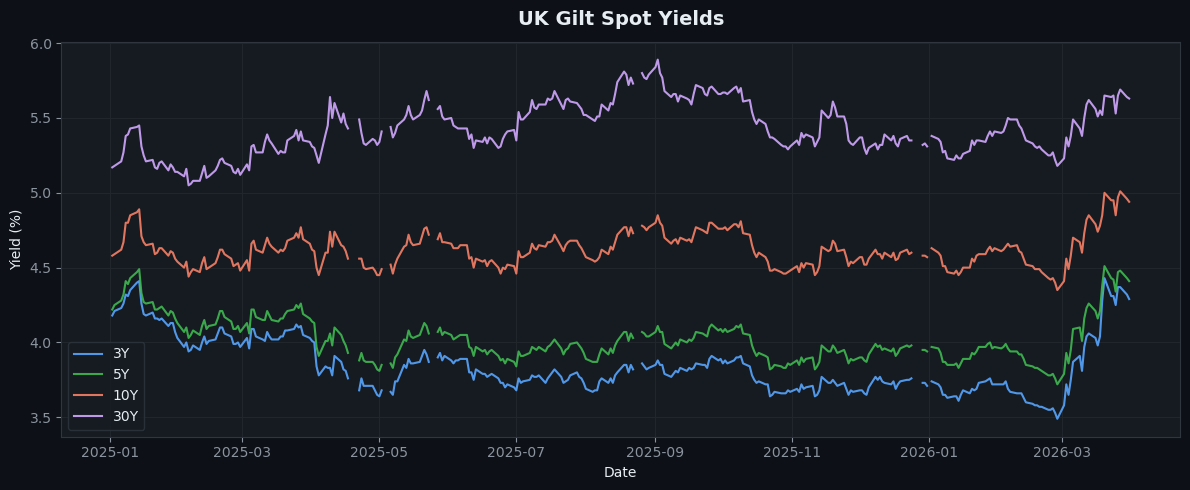

✅ Plot 1: Yield curve evolution saved


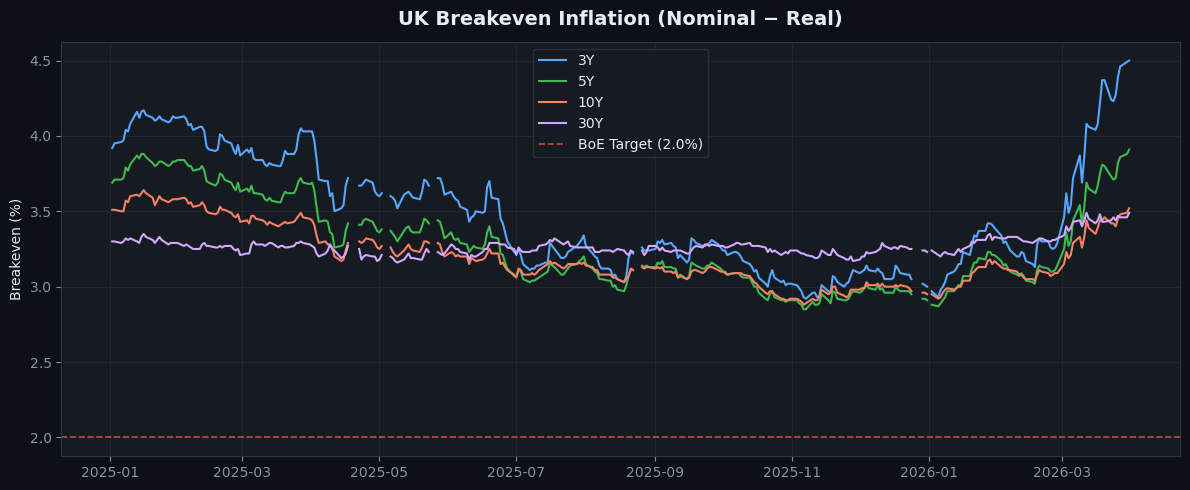

✅ Plot 2: Breakeven inflation saved

10Y Gilt Risk Metrics (at-par, semi-annual coupon):
  YTM:               4.940%
  Modified Duration: 7.8167 years
  Convexity:         73.9328

  DV01 (£1m notional): £782 per bp
  +1% yield move → price change: -7.447%
  -1% yield move → price change: +8.186%


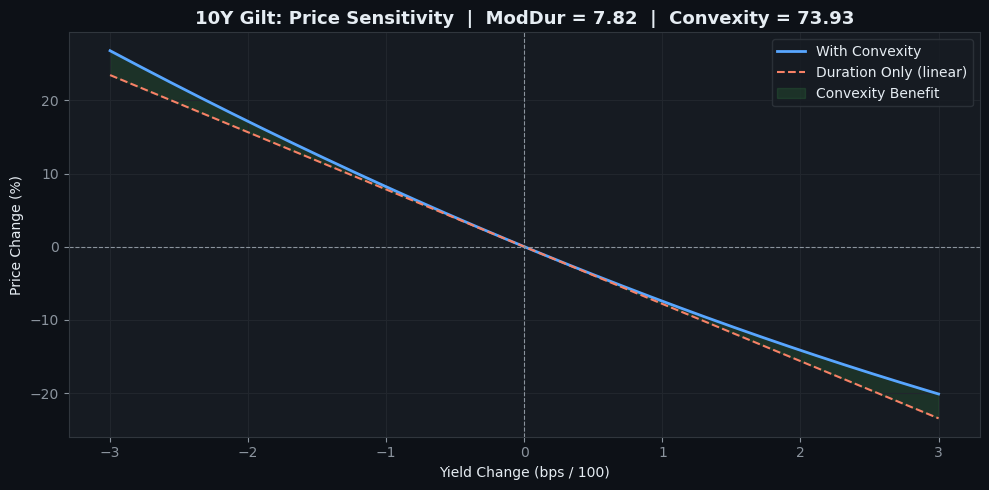

✅ Plot 3: Duration/convexity saved

5Y GBP IRS (receive-fixed, £1m notional):
  Par Swap Rate:  4.4100%
  Fixed Rate:     4.4100%
  Annuity:        4.406935
  Fixed Leg PV:   £194,346
  Floating Leg PV:£194,346
  MTM Value:      £-0  (at-market → ~£0)


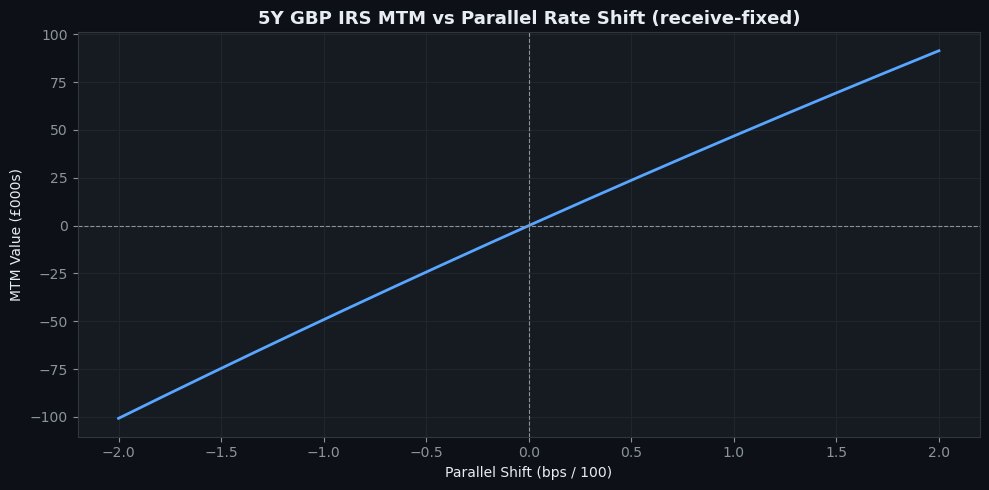

✅ Plot 4: Swap sensitivity saved

Relative Value Summary (latest):
  2s30s Slope:       +134.0 bps  (avg: 158.3 bps)
  2s10s30s Butterfly:-2.0 bps  (avg: -1.6 bps)


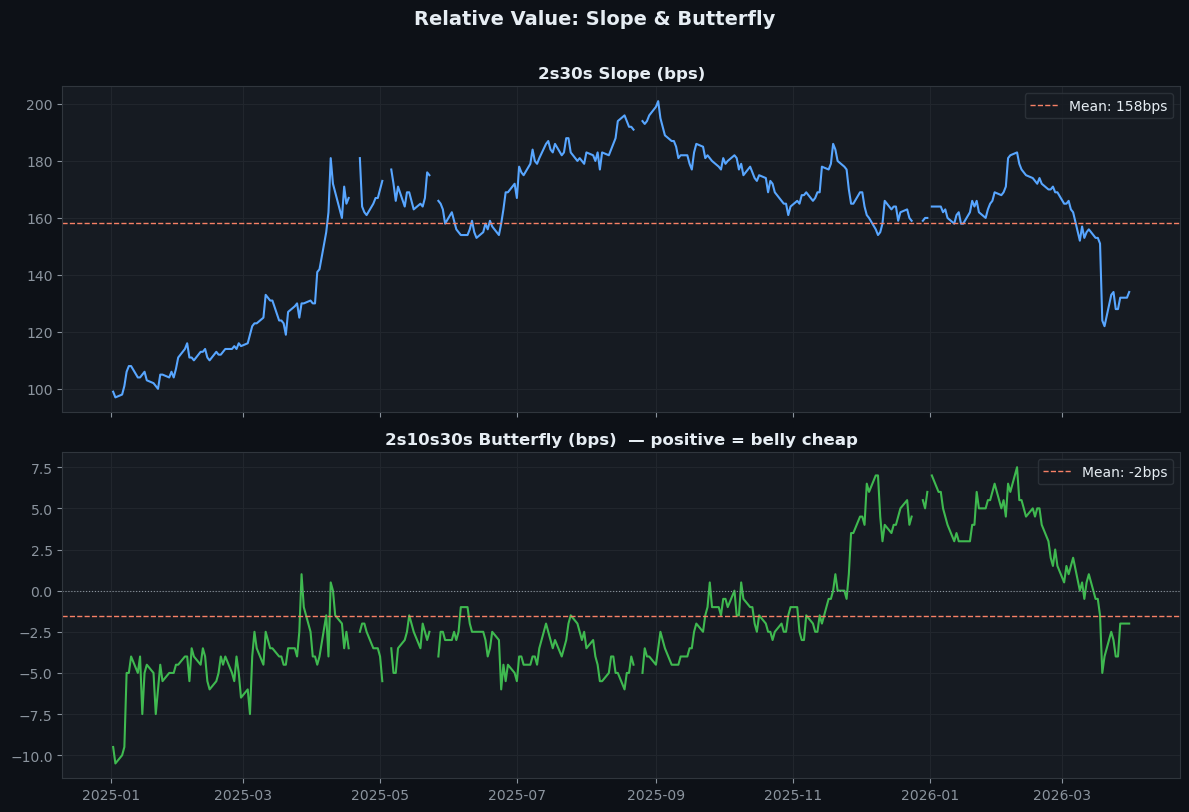

✅ Plot 5: RV analysis saved

PCA on Gilt Yield Changes:
  PC1 (Level     ): 90.0% variance explained
  PC2 (Slope     ): 8.1% variance explained
  PC3 (Curvature ): 0.8% variance explained


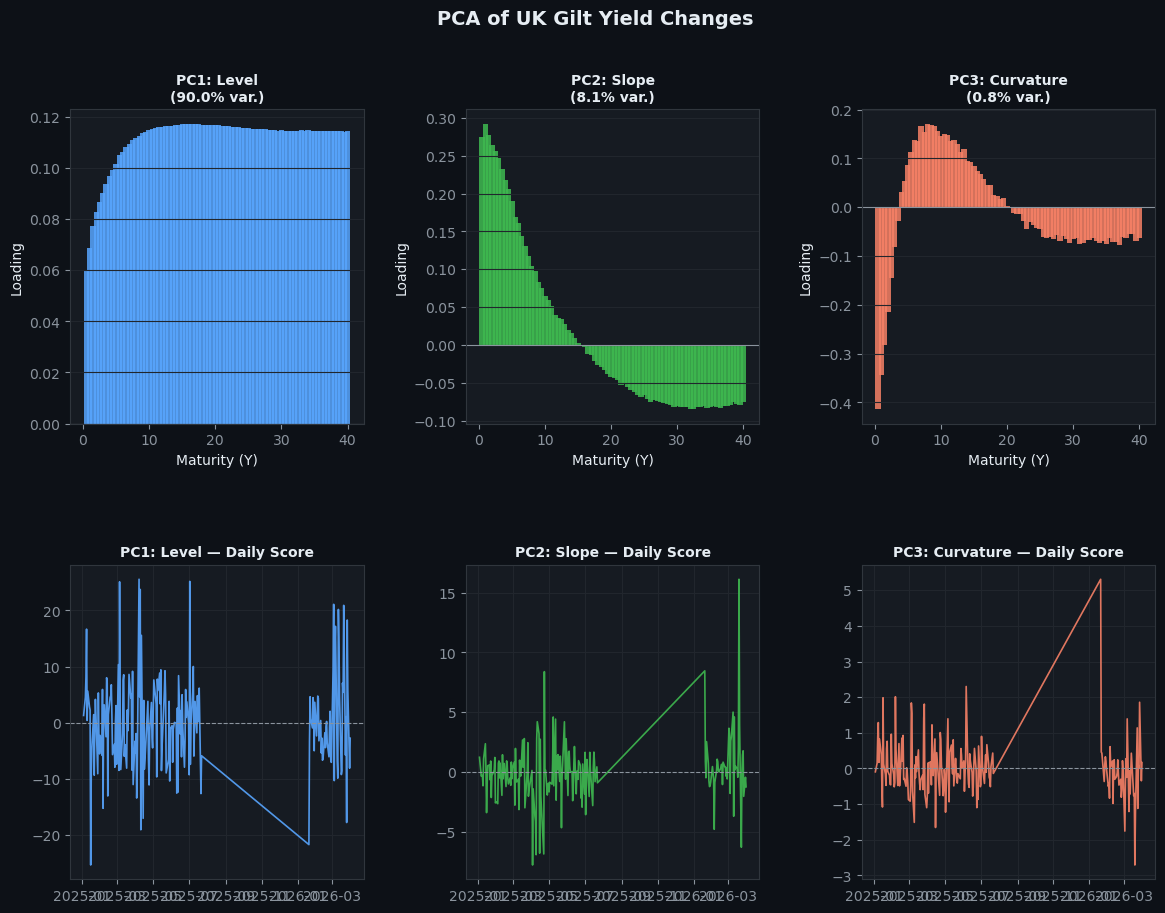

✅ Plot 6: PCA decomposition saved

✅ All analysis complete.


In [8]:
# ── Plotting ───────────────────────────────────────────────────────────────────

def plot_yield_curve_evolution(curve: pd.DataFrame) -> None:
    fig, ax = plt.subplots(figsize=(12, 5))
    for col, color in zip(curve.columns, COLORS):
        ax.plot(curve.index, curve[col], label=col, color=color, linewidth=1.5, alpha=0.9)
    ax.set_title('UK Gilt Spot Yields', fontsize=14, fontweight='bold', pad=12)
    ax.set_xlabel('Date')
    ax.set_ylabel('Yield (%)')
    ax.legend(framealpha=0.8)
    ax.grid(True)
    fig.tight_layout()
    fig.savefig('1_yield_curve_evolution.png', dpi=150)
    plt.show()
    print("✅ Plot 1: Yield curve evolution saved")


def plot_breakeven_inflation(breakeven: pd.DataFrame) -> None:
    fig, ax = plt.subplots(figsize=(12, 5))
    for col, color in zip(breakeven.columns, COLORS):
        ax.plot(breakeven.index, breakeven[col], label=col, color=color, linewidth=1.5)
    ax.axhline(BOE_TARGET, color='#f85149', linestyle='--', linewidth=1.2,
               alpha=0.8, label=f'BoE Target ({BOE_TARGET}%)')
    ax.set_title('UK Breakeven Inflation (Nominal − Real)', fontsize=14, fontweight='bold', pad=12)
    ax.set_ylabel('Breakeven (%)')
    ax.legend(framealpha=0.8)
    ax.grid(True)
    fig.tight_layout()
    fig.savefig('2_breakeven_inflation.png', dpi=150)
    plt.show()
    print("✅ Plot 2: Breakeven inflation saved")


def plot_duration_convexity(mod_dur: float, cvx: float,
                            ytm: float, label: str = '10Y') -> None:
    dy = np.linspace(-0.03, 0.03, 300)
    pct_change = price_change_pct(mod_dur, cvx, dy) * 100
    linear_approx = -mod_dur * dy * 100  # duration only

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(dy * 100, pct_change,     color=COLORS[0], linewidth=2,   label='With Convexity')
    ax.plot(dy * 100, linear_approx, color=COLORS[2], linewidth=1.5,
            linestyle='--', label='Duration Only (linear)')
    ax.axhline(0, color='#8b949e', linewidth=0.8, linestyle='--')
    ax.axvline(0, color='#8b949e', linewidth=0.8, linestyle='--')
    ax.fill_between(dy * 100, linear_approx, pct_change,
                    alpha=0.15, color=COLORS[1], label='Convexity Benefit')
    ax.set_title(f'{label} Gilt: Price Sensitivity  |  ModDur = {mod_dur:.2f}  |  Convexity = {cvx:.2f}',
                 fontsize=13, fontweight='bold')
    ax.set_xlabel('Yield Change (bps / 100)')
    ax.set_ylabel('Price Change (%)')
    ax.legend(framealpha=0.8)
    ax.grid(True)
    fig.tight_layout()
    fig.savefig('3_duration_convexity.png', dpi=150)
    plt.show()
    print("✅ Plot 3: Duration/convexity saved")


def plot_swap_sensitivity(fixed_rate: float, swap_maturity: int,
                          discount_factors: dict) -> None:
    bump_range = np.linspace(-0.02, 0.02, 200)
    mtm_values = []

    for bump in bump_range:
        bumped_dfs = {t: df * np.exp(-bump * t) for t, df in discount_factors.items()}
        result = price_irs(fixed_rate, swap_maturity, bumped_dfs)
        mtm_values.append(result['mtm_value'] / 1000)

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(bump_range * 100, mtm_values, color=COLORS[0], linewidth=2)
    ax.axhline(0, color='#8b949e', linewidth=0.8, linestyle='--')
    ax.axvline(0, color='#8b949e', linewidth=0.8, linestyle='--')
    ax.set_title(f'{swap_maturity}Y GBP IRS MTM vs Parallel Rate Shift (receive-fixed)',
                 fontsize=13, fontweight='bold')
    ax.set_xlabel('Parallel Shift (bps / 100)')
    ax.set_ylabel('MTM Value (£000s)')
    ax.grid(True)
    fig.tight_layout()
    fig.savefig('4_swap_sensitivity.png', dpi=150)
    plt.show()
    print("✅ Plot 4: Swap sensitivity saved")


def plot_rv_analysis(slope: pd.Series, butterfly: pd.Series) -> None:
    fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

    axes[0].plot(slope.index, slope, color=COLORS[0], linewidth=1.5)
    axes[0].axhline(slope.mean(), color=COLORS[2], linestyle='--',
                    linewidth=1, label=f'Mean: {slope.mean():.0f}bps')
    axes[0].set_title('2s30s Slope (bps)', fontsize=12, fontweight='bold')
    axes[0].legend()
    axes[0].grid(True)

    axes[1].plot(butterfly.index, butterfly, color=COLORS[1], linewidth=1.5)
    axes[1].axhline(butterfly.mean(), color=COLORS[2], linestyle='--',
                    linewidth=1, label=f'Mean: {butterfly.mean():.0f}bps')
    axes[1].axhline(0, color='#8b949e', linewidth=0.8, linestyle=':')
    axes[1].set_title('2s10s30s Butterfly (bps)  — positive = belly cheap', fontsize=12, fontweight='bold')
    axes[1].legend()
    axes[1].grid(True)

    fig.suptitle('Relative Value: Slope & Butterfly', fontsize=14, fontweight='bold', y=1.01)
    fig.tight_layout()
    fig.savefig('5_rv_analysis.png', dpi=150)
    plt.show()
    print("✅ Plot 5: RV analysis saved")


def plot_pca(pca_model, scores_df: pd.DataFrame,
             col_names: list, yields_matrix: pd.DataFrame) -> None:
    """Plot PCA factor loadings and time series scores."""
    fig = plt.figure(figsize=(14, 10))
    gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

    pc_names   = ['PC1: Level', 'PC2: Slope', 'PC3: Curvature']
    pc_colors  = [COLORS[0], COLORS[1], COLORS[2]]
    var_exp    = pca_model.explained_variance_ratio_

    # Top row: loadings (how each maturity loads onto each PC)
    maturities_float = [float(c) for c in col_names]
    for i in range(3):
        ax = fig.add_subplot(gs[0, i])
        loadings = pca_model.components_[i]
        ax.bar(maturities_float, loadings, color=pc_colors[i], alpha=0.85, width=0.8)
        ax.axhline(0, color='#8b949e', linewidth=0.8)
        ax.set_title(f'{pc_names[i]}\n({var_exp[i]*100:.1f}% var.)',
                     fontsize=10, fontweight='bold')
        ax.set_xlabel('Maturity (Y)')
        ax.set_ylabel('Loading')
        ax.grid(True, axis='y')

    # Bottom row: factor scores over time
    for i in range(3):
        ax = fig.add_subplot(gs[1, i])
        ax.plot(scores_df.index, scores_df[f'PC{i+1}'],
                color=pc_colors[i], linewidth=1.2, alpha=0.9)
        ax.axhline(0, color='#8b949e', linewidth=0.8, linestyle='--')
        ax.set_title(f'{pc_names[i]} — Daily Score', fontsize=10, fontweight='bold')
        ax.grid(True)

    fig.suptitle('PCA of UK Gilt Yield Changes', fontsize=14, fontweight='bold')
    fig.savefig('6_pca_decomposition.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✅ Plot 6: PCA decomposition saved")


# ── Main ───────────────────────────────────────────────────────────────────────

def main():
    # ── 1. Load data ──────────────────────────────────────────────────────────
    print("Loading data...")
    nominal_raw = load_glc(NOMINAL_PATH)
    real_raw    = load_glc(REAL_PATH)

    curve       = get_key_tenors(nominal_raw)
    real_curve  = get_key_tenors(real_raw)
    breakeven   = curve - real_curve

    print(f"Loaded {len(curve)} trading days | Last date: {curve.index[-1].date()}")
    print(curve.tail(3))

    # ── 2. Yield curve & breakeven plots ──────────────────────────────────────
    plot_yield_curve_evolution(curve)
    plot_breakeven_inflation(breakeven)

    # ── 3. Duration & Convexity (10Y gilt, at-par assumption) ─────────────────
    ytm_10y = curve['10Y'].iloc[-1] / 100
    mod_dur = modified_duration(ytm_10y, coupon_rate=ytm_10y, maturity=10)
    cvx     = convexity(ytm_10y, coupon_rate=ytm_10y, maturity=10)

    print(f"\n10Y Gilt Risk Metrics (at-par, semi-annual coupon):")
    print(f"  YTM:               {ytm_10y*100:.3f}%")
    print(f"  Modified Duration: {mod_dur:.4f} years")
    print(f"  Convexity:         {cvx:.4f}")
    print(f"\n  DV01 (£1m notional): £{mod_dur * NOTIONAL / 10_000:,.0f} per bp")
    print(f"  +1% yield move → price change: {price_change_pct(mod_dur, cvx, 0.01)*100:+.3f}%")
    print(f"  -1% yield move → price change: {price_change_pct(mod_dur, cvx, -0.01)*100:+.3f}%")

    plot_duration_convexity(mod_dur, cvx, ytm_10y, label='10Y')

    # ── 4. GBP IRS Pricing ────────────────────────────────────────────────────
    # Build integer-tenor spot curve for bootstrapping
    # ── 4. GBP IRS Pricing ────────────────────────────────────────────────────
    # Build integer-tenor spot curve for bootstrapping
    available_tenors = [t for t in nominal_raw.columns if 3 <= t <= 7.5]
    available_tenors = sorted([float(x) for x in available_tenors])
    spot_series = nominal_raw[available_tenors].iloc[-1]
    spot_series.index = available_tenors
    
    dfs = build_discount_factors(spot_series)
    
    swap_mat   = 5
    fixed_rate = curve['5Y'].iloc[-1] / 100   # at-market swap
    swap       = price_irs(fixed_rate, swap_mat, dfs)

    print(f"\n5Y GBP IRS (receive-fixed, £{NOTIONAL/1e6:.0f}m notional):")
    print(f"  Par Swap Rate:  {swap['swap_rate']*100:.4f}%")
    print(f"  Fixed Rate:     {fixed_rate*100:.4f}%")
    print(f"  Annuity:        {swap['annuity']:.6f}")
    print(f"  Fixed Leg PV:   £{swap['fixed_pv']:,.0f}")
    print(f"  Floating Leg PV:£{swap['floating_pv']:,.0f}")
    print(f"  MTM Value:      £{swap['mtm_value']:,.0f}  (at-market → ~£0)")

    plot_swap_sensitivity(fixed_rate, swap_mat, dfs)

    # ── 5. Relative Value: Slope & Butterfly ──────────────────────────────────
    slope     = compute_slope(curve)
    butterfly = compute_butterfly(curve)

    print(f"\nRelative Value Summary (latest):")
    print(f"  2s30s Slope:       {slope.iloc[-1]:+.1f} bps  (avg: {slope.mean():.1f} bps)")
    print(f"  2s10s30s Butterfly:{butterfly.iloc[-1]:+.1f} bps  (avg: {butterfly.mean():.1f} bps)")

    plot_rv_analysis(slope, butterfly)

    # ── 6. PCA Decomposition ──────────────────────────────────────────────────
    # Use all available maturities for a richer decomposition
    all_cols = [c for c in nominal_raw.columns if nominal_raw[c].notna().sum() > 10]
    yields_full = nominal_raw[all_cols].dropna()

    pca_model, scores_df = run_pca(yields_full)

    print("\nPCA on Gilt Yield Changes:")
    for i, var in enumerate(pca_model.explained_variance_ratio_):
        print(f"  PC{i+1} ({['Level','Slope','Curvature'][i]:10s}): {var*100:.1f}% variance explained")

    plot_pca(pca_model, scores_df, col_names=all_cols, yields_matrix=yields_full)

    print("\n✅ All analysis complete.")


if __name__ == "__main__":
    main()